# Kaggle Classical Baselines

This notebook evaluates classical machine learning baselines on the processed Kaggle Human-LLM Generated Phishing/Legitimate Emails dataset using TF-IDF features and the saved 60/40 train-test split. Four classifiers are evaluated: Multinomial Naive Bayes, Logistic Regression, Linear SVM, and Random Forest, with additional per-source analysis on human-generated and LLM-generated emails.

## 1. Import libraries and load processed data

This section imports the libraries used throughout the notebook and loads the processed Kaggle train and test splits for the classical baseline experiments.

In [25]:
import time
from pathlib import Path

import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import matplotlib.pyplot as plt

This section loads the processed Kaggle train and test files and confirms the split sizes before any verification or modelling begins.

In [26]:
data_dir = Path("../data/processed/kaggle/")

train_df = pd.read_parquet(data_dir / "kaggle_train_60.parquet")
test_df = pd.read_parquet(data_dir / "kaggle_test_40.parquet")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (1435, 3)
Test shape: (957, 3)


## 2. Verify the saved split

This section confirms that the processed train and test files contain the expected columns, class distribution, and source coverage before modelling begins.

In [27]:
print("Train columns:", train_df.columns.tolist())
print("Test columns:", test_df.columns.tolist())
print()

print("Train label distribution:")
print(train_df["label"].value_counts())
print()
print(train_df["label"].value_counts(normalize=True))
print()

print("Test label distribution:")
print(test_df["label"].value_counts())
print()
print(test_df["label"].value_counts(normalize=True))

Train columns: ['text', 'label', 'source']
Test columns: ['text', 'label', 'source']

Train label distribution:
label
0    1034
1     401
Name: count, dtype: int64

label
0    0.720557
1    0.279443
Name: proportion, dtype: float64

Test label distribution:
label
0    690
1    267
Name: count, dtype: int64

label
0    0.721003
1    0.278997
Name: proportion, dtype: float64


In [28]:
display(train_df.head(3))

,text,label,source
0,Rachel Thompson COVID-19 Vaccination Team,1,llm-generated
1,Notification: jose@monkey.org Dear jose To c...,1,human-generated
2,ActiveState evaluation license for Komodo IDE ...,0,human-generated


In [29]:
print("Train source breakdown:")
print(train_df["source"].value_counts())
print()
print("Test source breakdown:")
print(test_df["source"].value_counts())

Train source breakdown:
source
human-generated    762
llm-generated      673
Name: count, dtype: int64

Test source breakdown:
source
llm-generated      489
human-generated    468
Name: count, dtype: int64


## 3. Train and evaluate TF-IDF + Multinomial Naive Bayes

This section builds TF-IDF features from the Kaggle training data and evaluates a Multinomial Naive Bayes baseline on the Kaggle test set.

In [30]:
X_train = train_df["text"]
y_train = train_df["label"]
X_test = test_df["text"]
y_test = test_df["label"]
source_test = test_df["source"]

vectoriser = TfidfVectorizer(max_features=50000, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf = vectoriser.fit_transform(X_train)
X_test_tfidf = vectoriser.transform(X_test)

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)
print("Vocabulary size:", X_train_tfidf.shape[1])

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

start_time = time.perf_counter()
nb_pred = nb_model.predict(X_test_tfidf)
end_time = time.perf_counter()

tn, fp, fn, tp = confusion_matrix(y_test, nb_pred).ravel()

results_nb = {
    "dataset": "Kaggle",
    "model": "TF-IDF + MultinomialNB",
    "accuracy": accuracy_score(y_test, nb_pred),
    "precision": precision_score(y_test, nb_pred, zero_division=0),
    "recall": recall_score(y_test, nb_pred, zero_division=0),
    "f1": f1_score(y_test, nb_pred, zero_division=0),
    "false_positive_rate": fp / (fp + tn),
    "inference_time_total_sec": end_time - start_time,
    "inference_time_per_email_sec": (end_time - start_time) / len(X_test),
    "train_rows": len(train_df),
    "test_rows": len(test_df),
    "vocab_size": X_train_tfidf.shape[1],
}

pd.DataFrame([results_nb])

TF-IDF train shape: (1435, 50000)
TF-IDF test shape: (957, 50000)
Vocabulary size: 50000


,dataset,model,accuracy,precision,recall,f1,false_positive_rate,inference_time_total_sec,inference_time_per_email_sec,train_rows,test_rows,vocab_size
0,Kaggle,TF-IDF + MultinomialNB,0.863114,1.0,0.509363,0.674938,0.0,0.001251,0.000001,1435,957,50000


## 4. Train and evaluate TF-IDF + Logistic Regression

This section evaluates a Logistic Regression classifier using the same TF-IDF representation so that results can be compared fairly against Multinomial Naive Bayes.

In [31]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)

start_time = time.perf_counter()
lr_pred = lr_model.predict(X_test_tfidf)
end_time = time.perf_counter()

tn, fp, fn, tp = confusion_matrix(y_test, lr_pred).ravel()

results_lr = {
    "dataset": "Kaggle",
    "model": "TF-IDF + LogisticRegression",
    "accuracy": accuracy_score(y_test, lr_pred),
    "precision": precision_score(y_test, lr_pred, zero_division=0),
    "recall": recall_score(y_test, lr_pred, zero_division=0),
    "f1": f1_score(y_test, lr_pred, zero_division=0),
    "false_positive_rate": fp / (fp + tn),
    "inference_time_total_sec": end_time - start_time,
    "inference_time_per_email_sec": (end_time - start_time) / len(X_test),
    "train_rows": len(train_df),
    "test_rows": len(test_df),
    "vocab_size": X_train_tfidf.shape[1],
}

pd.DataFrame([results_lr])

,dataset,model,accuracy,precision,recall,f1,false_positive_rate,inference_time_total_sec,inference_time_per_email_sec,train_rows,test_rows,vocab_size
0,Kaggle,TF-IDF + LogisticRegression,0.941484,1.0,0.790262,0.882845,0.0,0.001313,0.000001,1435,957,50000


## 5. Train and evaluate TF-IDF + Linear SVM

This section evaluates a linear Support Vector Machine using the same TF-IDF features and evaluation framework.

In [32]:
svm_model = LinearSVC(max_iter=2000, random_state=42)
svm_model.fit(X_train_tfidf, y_train)

start_time = time.perf_counter()
svm_pred = svm_model.predict(X_test_tfidf)
end_time = time.perf_counter()

tn, fp, fn, tp = confusion_matrix(y_test, svm_pred).ravel()

results_svm = {
    "dataset": "Kaggle",
    "model": "TF-IDF + LinearSVM",
    "accuracy": accuracy_score(y_test, svm_pred),
    "precision": precision_score(y_test, svm_pred, zero_division=0),
    "recall": recall_score(y_test, svm_pred, zero_division=0),
    "f1": f1_score(y_test, svm_pred, zero_division=0),
    "false_positive_rate": fp / (fp + tn),
    "inference_time_total_sec": end_time - start_time,
    "inference_time_per_email_sec": (end_time - start_time) / len(X_test),
    "train_rows": len(train_df),
    "test_rows": len(test_df),
    "vocab_size": X_train_tfidf.shape[1],
}

pd.DataFrame([results_svm])

,dataset,model,accuracy,precision,recall,f1,false_positive_rate,inference_time_total_sec,inference_time_per_email_sec,train_rows,test_rows,vocab_size
0,Kaggle,TF-IDF + LinearSVM,0.990596,0.996154,0.970037,0.982922,0.001449,0.000344,3.598924e-07,1435,957,50000


## 6. Train and evaluate TF-IDF + Random Forest

This section evaluates a Random Forest classifier using the same TF-IDF features and evaluation framework, extending the three-model baseline with an ensemble method.

In [33]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_tfidf, y_train)

start_time = time.perf_counter()
rf_pred = rf_model.predict(X_test_tfidf)
end_time = time.perf_counter()

tn, fp, fn, tp = confusion_matrix(y_test, rf_pred).ravel()

results_rf = {
    "dataset": "Kaggle",
    "model": "TF-IDF + RandomForest",
    "accuracy": accuracy_score(y_test, rf_pred),
    "precision": precision_score(y_test, rf_pred, zero_division=0),
    "recall": recall_score(y_test, rf_pred, zero_division=0),
    "f1": f1_score(y_test, rf_pred, zero_division=0),
    "false_positive_rate": fp / (fp + tn),
    "inference_time_total_sec": end_time - start_time,
    "inference_time_per_email_sec": (end_time - start_time) / len(X_test),
    "train_rows": len(train_df),
    "test_rows": len(test_df),
    "vocab_size": X_train_tfidf.shape[1],
}

pd.DataFrame([results_rf])

,dataset,model,accuracy,precision,recall,f1,false_positive_rate,inference_time_total_sec,inference_time_per_email_sec,train_rows,test_rows,vocab_size
0,Kaggle,TF-IDF + RandomForest,0.983281,0.996047,0.94382,0.969231,0.001449,0.026585,0.000028,1435,957,50000


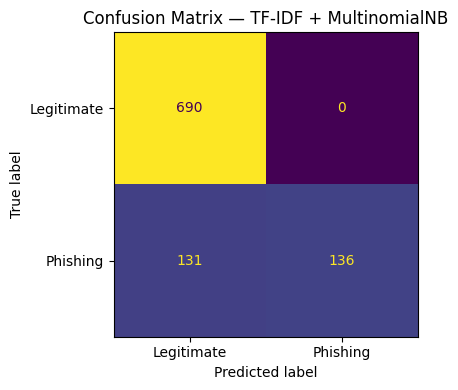

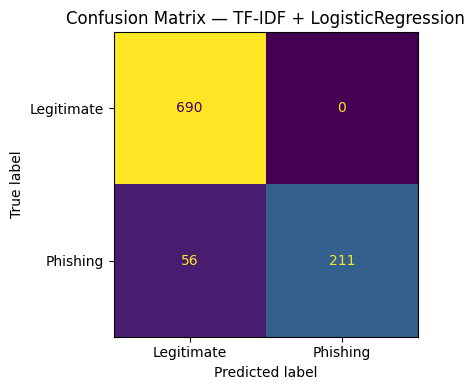

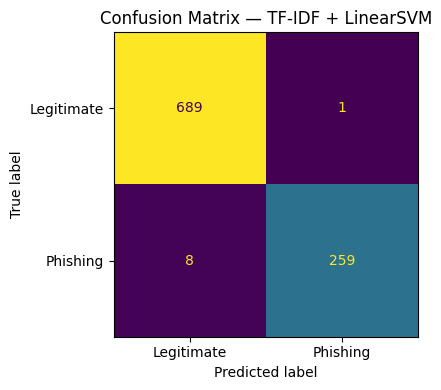

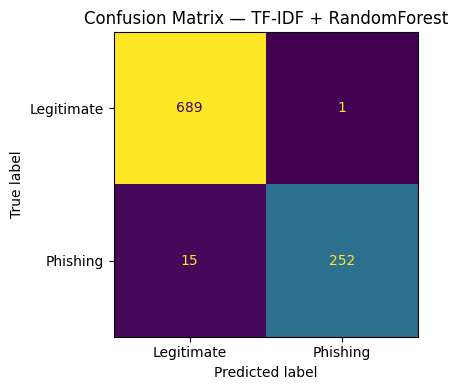

In [34]:
trained_models = {
    "TF-IDF + MultinomialNB": nb_pred,
    "TF-IDF + LogisticRegression": lr_pred,
    "TF-IDF + LinearSVM": svm_pred,
    "TF-IDF + RandomForest": rf_pred,
}

figures_dir = Path("../results/figures/")
figures_dir.mkdir(parents=True, exist_ok=True)

for name, y_pred in trained_models.items():
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitimate", "Phishing"])

    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"Confusion Matrix — {name}")
    plt.tight_layout()

    plt.savefig(figures_dir / f"kaggle_cm_{name.lower().replace(' ', '_')}.png", dpi=150)
    plt.show()

## 7. Summary Results Table
A clean side-by-side comparison of all four models on the key deployment-relevant metrics: overall accuracy, F1-score on the phishing class, False Positive Rate, and inference time. This table is the primary reference for the final report and summarises the Kaggle baseline results in the same format used for MeAJOR.

In [35]:
summary_rows = [
    {k: v for k, v in r.items() if k in ["model", "accuracy", "f1", "false_positive_rate", "inference_time_total_sec"]}
    for r in [results_nb, results_lr, results_svm, results_rf]
]
summary_df = pd.DataFrame(summary_rows).rename(columns={
    "model": "Model",
    "accuracy": "Accuracy",
    "f1": "F1 (Phishing)",
    "false_positive_rate": "FPR",
    "inference_time_total_sec": "Inference Time (s)",
})

print(summary_df.to_string(index=False))

                      Model  Accuracy  F1 (Phishing)      FPR  Inference Time (s)
     TF-IDF + MultinomialNB  0.863114       0.674938 0.000000            0.001251
TF-IDF + LogisticRegression  0.941484       0.882845 0.000000            0.001313
         TF-IDF + LinearSVM  0.990596       0.982922 0.001449            0.000344
      TF-IDF + RandomForest  0.983281       0.969231 0.001449            0.026585


### Per-source breakdown

This subsection evaluates each model separately on human-generated and LLM-generated emails to show whether performance is consistent across both sources. The comparison helps distinguish genuine phishing detection from source-specific writing style effects.

In [36]:
human_mask = source_test.values == "human-generated"
llm_mask = source_test.values == "llm-generated"

for name, y_pred in trained_models.items():
    print(f"\n{'=' * 55}")
    print(f"  {name}")
    print(f"{'=' * 55}")

    print("  >> Human-generated emails:")
    print(classification_report(
        y_test[human_mask],
        y_pred[human_mask],
        target_names=["Legitimate (0)", "Phishing (1)"],
        zero_division=0,
    ))

    print("  >> LLM-generated emails:")
    print(classification_report(
        y_test[llm_mask],
        y_pred[llm_mask],
        target_names=["Legitimate (0)", "Phishing (1)"],
        zero_division=0,
    ))


  TF-IDF + MultinomialNB
  >> Human-generated emails:
                precision    recall  f1-score   support

Legitimate (0)       0.80      1.00      0.89       266
  Phishing (1)       1.00      0.66      0.80       202

      accuracy                           0.85       468
     macro avg       0.90      0.83      0.84       468
  weighted avg       0.88      0.85      0.85       468

  >> LLM-generated emails:
                precision    recall  f1-score   support

Legitimate (0)       0.87      1.00      0.93       424
  Phishing (1)       1.00      0.03      0.06        65

      accuracy                           0.87       489
     macro avg       0.94      0.52      0.50       489
  weighted avg       0.89      0.87      0.82       489


  TF-IDF + LogisticRegression
  >> Human-generated emails:
                precision    recall  f1-score   support

Legitimate (0)       0.88      1.00      0.94       266
  Phishing (1)       1.00      0.82      0.90       202

      accu

## 8. Save classical baseline results

This section combines the results from all four classical models and saves them for later comparison and reporting.

**Note:** In addition to standard accuracy and F1, this notebook also records **inference time** and **False Positive Rate (FPR)** for each model. These deployment-relevant metrics are important for this project: inference time determines real-time viability, and FPR measures how often legitimate emails are wrongly flagged as phishing.

In [37]:
results_dir = Path("../results/metrics")
results_dir.mkdir(parents=True, exist_ok=True)

results_classical = pd.DataFrame([results_nb, results_lr, results_svm, results_rf])
results_classical.to_csv(results_dir / "kaggle_classical_baseline_results.csv", index=False)

print(results_classical)
print()
print("Saved to:", results_dir / "kaggle_classical_baseline_results.csv")

  dataset                        model  accuracy  precision    recall  \
0  Kaggle       TF-IDF + MultinomialNB  0.863114   1.000000  0.509363   
1  Kaggle  TF-IDF + LogisticRegression  0.941484   1.000000  0.790262   
2  Kaggle           TF-IDF + LinearSVM  0.990596   0.996154  0.970037   
3  Kaggle        TF-IDF + RandomForest  0.983281   0.996047  0.943820   

         f1  false_positive_rate  inference_time_total_sec  \
0  0.674938             0.000000                  0.001251   
1  0.882845             0.000000                  0.001313   
2  0.982922             0.001449                  0.000344   
3  0.969231             0.001449                  0.026585   

   inference_time_per_email_sec  train_rows  test_rows  vocab_size  
0                  1.307383e-06        1435        957       50000  
1                  1.371473e-06        1435        957       50000  
2                  3.598924e-07        1435        957       50000  
3                  2.777935e-05        1435    